# 01 — Load Data (Goodreads + Top-Up)

**Primary source** — real Goodreads book descriptions with genre shelves:  
- `Eitanli/goodreads` (~10K books, Genres list + Description)  
- `pszemraj/goodreads-bookgenres` (~10K books, Children & Young Adult genre label)

**Top-up sources** for buckets Goodreads can't fill (picture books / middle-grade are rare there):  
- `+4` → `roneneldan/TinyStories` (synthetic stories for young children)  
- `+10` → `ajibawa-2023/Children-Stories-Collection` (synthetic middle-grade stories)

All downloads use `requests` + `pyarrow` via the HF `/api/parquet` endpoint — **no `datasets` library, no torch, no DLL issues.**

| Age Group | Goodreads Shelf Keywords |
|-----------|---------------------------|
| `+4`      | picture book, early reader, board book, preschool |
| `+10`     | middle grade, childrens, juvenile |
| `+12`     | young adult, ya, teen, children & young adult |
| `+18`     | thriller, mystery, romance, horror, adult fiction, etc. |

## Imports & Config

In [30]:
# Requirements: pip install requests pyarrow pandas matplotlib
import requests
import pyarrow.parquet as pq
import pandas as pd
import ast, re, io, warnings
warnings.filterwarnings('ignore')

SAMPLES_PER_CLASS = 2000
TRUNCATE_WORDS    = 200
MIN_SUMMARY_WORDS = 20
RANDOM_STATE      = 42

print("✅ Imports done!")

✅ Imports done!


## Helper: Resolve & Download Parquet from HF

In [31]:
def get_hf_parquet_urls(repo_id, split="train"):
    """Query HF /api/parquet to get real file URLs — no hardcoded filenames."""
    api_url = f"https://huggingface.co/api/datasets/{repo_id}/parquet"
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    urls = []
    if isinstance(data, dict):
        for config_val in data.values():
            if isinstance(config_val, dict) and split in config_val:
                urls.extend(config_val[split])
            elif isinstance(config_val, list):
                urls.extend(config_val)
    elif isinstance(data, list):
        urls = [f["url"] for f in data if f.get("split") == split]
    print(f"  {repo_id} [{split}]: {len(urls)} shard(s) found")
    return urls


def download_parquet(urls, max_shards=None):
    """Download parquet shards into a single DataFrame."""
    if max_shards:
        urls = urls[:max_shards]
    frames = []
    for i, url in enumerate(urls):
        fname = url.split('/')[-1].split('?')[0]
        print(f"  Shard {i+1}/{len(urls)}: {fname} ...", end=" ", flush=True)
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        df = pq.read_table(io.BytesIO(r.content)).to_pandas()
        frames.append(df)
        print(f"{len(df):,} rows")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


print("✅ Helper functions ready")

✅ Helper functions ready


## Load Goodreads Sources

In [32]:
print("=== Source 1: Eitanli/goodreads ===")
urls1 = get_hf_parquet_urls("Eitanli/goodreads")
df1   = download_parquet(urls1)
print(f"Loaded: {len(df1):,} rows | Columns: {list(df1.columns)}\n")

print("=== Source 2: pszemraj/goodreads-bookgenres ===")
urls2 = get_hf_parquet_urls("pszemraj/goodreads-bookgenres")
df2   = download_parquet(urls2)
print(f"Loaded: {len(df2):,} rows | Columns: {list(df2.columns)}")

=== Source 1: Eitanli/goodreads ===
  Eitanli/goodreads [train]: 1 shard(s) found
  Shard 1/1: 0.parquet ... 10,000 rows
Loaded: 10,000 rows | Columns: ['Unnamed: 0', 'Book', 'Author', 'Description', 'Genres', 'Avg_Rating', 'Num_Ratings', 'URL']

=== Source 2: pszemraj/goodreads-bookgenres ===
  pszemraj/goodreads-bookgenres [train]: 4 shard(s) found
  Shard 1/4: 0.parquet ... 7,914 rows
  Shard 2/4: 0.parquet ... 7,914 rows
  Shard 3/4: 0.parquet ... 9,923 rows
  Shard 4/4: 0.parquet ... 7,914 rows
Loaded: 33,665 rows | Columns: ['Book', 'Description', 'Genres', 'predicted_genres']


In [33]:
# Decode pszemraj's multi-hot Genres vector into genre name strings
PSZEMRAJ_GENRES = [
    'History & Politics', 'Health & Medicine', 'Mystery & Thriller',
    'Arts & Design', 'Self-Help & Wellness', 'Sports & Recreation',
    'Non-Fiction', 'Science Fiction & Fantasy', 'Countries & Geography',
    'Other', 'Nature & Environment', 'Business & Finance',
    'Romance', 'Philosophy & Religion', 'Literature & Fiction',
    'Science & Technology', 'Children & Young Adult', 'Food & Cooking'
]

def decode_genres(vec):
    if not isinstance(vec, (list, tuple)):
        return []
    return [PSZEMRAJ_GENRES[i] for i, v in enumerate(vec) if v == 1]

df2["Genres"] = df2["Genres"].apply(decode_genres)
print(f"Sample pszemraj genres: {df2['Genres'].iloc[0]}")

Sample pszemraj genres: []


## Normalise & Merge Goodreads Sources

In [34]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()

TEXT_COLS  = ["Description", "description", "summary", "overview"]
GENRE_COLS = ["Genres", "genres", "Genre", "genre"]
pick = lambda df, cols: next((c for c in cols if c in df.columns), None)

def normalise(df, label):
    tc, gc = pick(df, TEXT_COLS), pick(df, GENRE_COLS)
    print(f"  [{label}] text='{tc}'  genres='{gc}'")
    out = pd.DataFrame()
    out["text"]       = df[tc].apply(clean_text)
    out["genres_raw"] = df[gc]
    return out

goodreads = pd.concat([normalise(df1, "Eitanli"),
                       normalise(df2, "pszemraj")], ignore_index=True)
print(f"\nGoodreads combined: {len(goodreads):,} rows")

  [Eitanli] text='Description'  genres='Genres'
  [pszemraj] text='Description'  genres='Genres'

Goodreads combined: 43,665 rows


## Shelf → Age Group Mapping

In [35]:
SHELF_RULES = [
    ("+4",  ["picture book", "picture-book", "early reader", "early-reader",
              "board book", "preschool", "kindergarten",
              "ages 3", "ages 4", "ages 5", "ages 6"]),
    ("+10", ["middle grade", "middle-grade", "middlegrade",
              "childrens", "children\u2019s fiction", "juvenile",
              "kids fiction", "kids-fiction",
              "ages 8", "ages 9", "ages 10", "ages 11"]),
    ("+12", ["young adult", "young-adult", "ya fiction", "ya-fiction",
              "teen", "children & young adult", "children and young adult",
              "ages 12", "ages 13", "ages 14", "ages 15", "ages 16"]),
    ("+18", ["adult fiction", "adult-fiction", "literary fiction",
              "thriller", "mystery", "romance", "horror", "erotica",
              "science fiction", "fantasy", "historical fiction",
              "contemporary fiction", "crime", "mature", "new adult",
              "literature & fiction", "mystery & thriller",
              "science fiction & fantasy"]),
]

def assign_age_group(genres_raw):
    if genres_raw is None or isinstance(genres_raw, float):
        return None
    genres = genres_raw if isinstance(genres_raw, list) else (
        ast.literal_eval(str(genres_raw))
        if str(genres_raw).startswith('[') else [str(genres_raw)]
    )
    combined = " ".join(str(g).lower() for g in genres)
    for label, keywords in SHELF_RULES:
        if any(kw in combined for kw in keywords):
            return label
    return None

assert assign_age_group(["Young Adult", "Fantasy"])    == "+12"
assert assign_age_group(["Picture Book"])              == "+4"
assert assign_age_group(["Thriller"])                  == "+18"
assert assign_age_group(["Middle Grade"])              == "+10"
assert assign_age_group(["Children & Young Adult"])    == "+12"
print("✅ Shelf rules ready")

✅ Shelf rules ready


In [36]:
goodreads["age_group"] = goodreads["genres_raw"].apply(assign_age_group)
df_labeled = goodreads[goodreads["age_group"].notna()].copy()
df_labeled = df_labeled[df_labeled["text"].apply(lambda x: len(x.split()) >= MIN_SUMMARY_WORDS)]
df_labeled = df_labeled.drop_duplicates(subset="text").reset_index(drop=True)

print("Goodreads labeled counts:")
print(df_labeled["age_group"].value_counts().sort_index())

bucket_counts = df_labeled["age_group"].value_counts()
for lb in ["+4", "+10", "+12", "+18"]:
    have    = bucket_counts.get(lb, 0)
    deficit = max(0, SAMPLES_PER_CLASS - have)
    status  = "✅" if deficit == 0 else f"⚠️  needs {deficit} more"
    print(f"  {lb}: {have:>4}  {status}")

Goodreads labeled counts:
age_group
+10     563
+12    1041
+18    4104
+4      156
Name: count, dtype: int64
  +4:  156  ⚠️  needs 1844 more
  +10:  563  ⚠️  needs 1437 more
  +12: 1041  ⚠️  needs 959 more
  +18: 4104  ✅


## Top-Up Underfilled Buckets

- **+4** topped up from `roneneldan/TinyStories` (simple vocabulary, young-child stories)
- **+10** topped up from `ajibawa-2023/Children-Stories-Collection` (middle-grade level)

In [37]:
TOP_UP_SOURCES = {
    "+4":  ("roneneldan/TinyStories",                  "text"),
    "+10": ("ajibawa-2023/Children-Stories-Collection", "text"),
    "+12": ("ajibawa-2023/General-Stories-Collection",  "text"),
}

topup_frames = [df_labeled[["text", "age_group"]]]

for label, (repo_id, text_col) in TOP_UP_SOURCES.items():
    have    = bucket_counts.get(label, 0)
    deficit = SAMPLES_PER_CLASS - have
    if deficit <= 0:
        print(f"{label}: no top-up needed ✅")
        continue

    print(f"\n{label}: fetching {deficit} extra rows from {repo_id} ...")
    urls = get_hf_parquet_urls(repo_id)

    collected = []
    for url in urls:
        if len(collected) >= deficit * 2:
            break
        fname = url.split('/')[-1].split('?')[0]
        print(f"  Shard: {fname} ...", end=" ", flush=True)
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        shard = pq.read_table(io.BytesIO(r.content)).to_pandas()
        print(f"{len(shard):,} rows")

        # Grab the text column (handle both 'text' and other names)
        col = text_col if text_col in shard.columns else shard.columns[0]
        texts = (
            shard[col].dropna()
            .apply(lambda x: clean_text(str(x)))
            .loc[lambda s: s.apply(lambda x: len(x.split()) >= MIN_SUMMARY_WORDS)]
            .tolist()
        )
        collected.extend(texts)

    # Truncate to exactly what we need
    topup = pd.DataFrame({
        "text":      collected[:deficit],
        "age_group": label
    })
    topup_frames.append(topup)
    print(f"  ✅ {label} top-up: +{len(topup)} samples")

df_combined = pd.concat(topup_frames, ignore_index=True)
print(f"\nFinal counts before balancing:")
print(df_combined["age_group"].value_counts().sort_index())


+4: fetching 1844 extra rows from roneneldan/TinyStories ...
  roneneldan/TinyStories [train]: 4 shard(s) found
  Shard: 0.parquet ... 529,930 rows
  ✅ +4 top-up: +1844 samples

+10: fetching 1437 extra rows from ajibawa-2023/Children-Stories-Collection ...
  ajibawa-2023/Children-Stories-Collection [train]: 5 shard(s) found
  Shard: 0.parquet ... 179,605 rows
  ✅ +10 top-up: +1437 samples

+12: fetching 959 extra rows from ajibawa-2023/General-Stories-Collection ...
  ajibawa-2023/General-Stories-Collection [train]: 5 shard(s) found
  Shard: 0.parquet ... 258,732 rows
  ✅ +12 top-up: +959 samples

Final counts before balancing:
age_group
+10    2000
+12    2000
+18    4104
+4     2000
Name: count, dtype: int64


## Inspect Samples per Class

In [38]:
for label in ["+4", "+10", "+12", "+18"]:
    subset = df_combined[df_combined["age_group"] == label]
    print(f"\n{'='*60}")
    print(f"  {label}  ({len(subset):,} samples) — example:")
    print(f"{'='*60}")
    print(subset.iloc[0]["text"][:400] if len(subset) else "  ⚠️  Empty!")


  +4  (2,000 samples) — example:
"Once there was a tree...and she loved a little boy."So begins a story of unforgettable perception, beautifully written and illustrated by the gifted and versatile Shel Silverstein.Every day the boy would come to the tree to eat her apples, swing from her branches, or slide down her trunk...and the tree was happy. But as the boy grew older he began to want more from the tree, and the tree gave and

  +10  (2,000 samples) — example:
Harry Potter thinks he is an ordinary boy - until he is rescued by an owl, taken to Hogwarts School of Witchcraft and Wizardry, learns to play Quidditch and does battle in a deadly duel. The Reason ... HARRY POTTER IS A WIZARD!

  +12  (2,000 samples) — example:
The unforgettable novel of a childhood in a sleepy Southern town and the crisis of conscience that rocked it. "To Kill A Mockingbird" became both an instant bestseller and a critical success when it was first published in 1960. It went on to win the Pulitzer Prize in

## Truncate, Balance & Save

In [39]:
def truncate(text, n=TRUNCATE_WORDS):
    words = text.split()
    return " ".join(words[:n]) if len(words) > n else text

balanced = []
for label in ["+4", "+10", "+12", "+18"]:
    group = df_combined[df_combined["age_group"] == label][["text", "age_group"]].copy()
    group["text"] = group["text"].apply(truncate)
    n = min(SAMPLES_PER_CLASS, len(group))
    if n == 0:
        print(f"   {label}: ⚠️  0 samples — skipping")
        continue
    balanced.append(group.sample(n=n, random_state=RANDOM_STATE))
    print(f"   {label}: {n} samples ✅")

df_final = pd.concat(balanced, ignore_index=True)
df_final = df_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_final.to_csv("data_raw.csv", index=False)

print(f"\n✅ Saved data_raw.csv — {len(df_final)} rows")
print(df_final["age_group"].value_counts().sort_index())

   +4: 2000 samples ✅
   +10: 2000 samples ✅
   +12: 2000 samples ✅
   +18: 2000 samples ✅

✅ Saved data_raw.csv — 8000 rows
age_group
+10    2000
+12    2000
+18    2000
+4     2000
Name: count, dtype: int64


## Class Distribution Plot

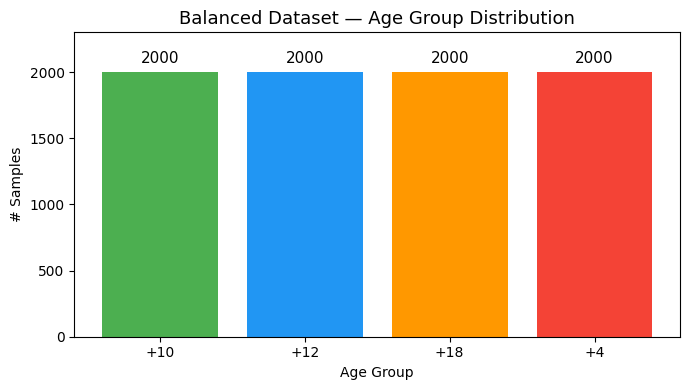

✅ Saved class_distribution.png


In [40]:
import matplotlib.pyplot as plt

counts = df_final["age_group"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=["#4CAF50", "#2196F3", "#FF9800", "#F44336"])
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title("Balanced Dataset — Age Group Distribution", fontsize=13)
ax.set_xlabel("Age Group")
ax.set_ylabel("# Samples")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Saved class_distribution.png")

## Preview Final Dataset

In [41]:
print(f"Shape: {df_final.shape}")
df_final["wc"] = df_final["text"].apply(lambda x: len(x.split()))
print("\nAvg word count per class:")
print(df_final.groupby("age_group")["wc"].mean().round(1))
df_final.drop(columns=["wc"], inplace=True)
df_final.head(6)

Shape: (8000, 2)

Avg word count per class:
age_group
+10    176.6
+12    170.8
+18    140.5
+4     149.0
Name: wc, dtype: float64


,text,age_group
0,"Once upon a time in a bustling city, there was...",+10
1,In a small town lived a curious little boy nam...,+10
2,Once upon a time there was a boy called Tom. H...,+4
3,"One sunny day, Sally and her dog Max were play...",+10
4,Once upon a time there was a girl who was spec...,+12
5,"In a cozy corner of the earth, near a big moun...",+10
